In [111]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [112]:
#加载数据集
from sklearn.datasets import load_diabetes

RANDOM_SEED = 42
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X.dtype:", X.dtype)
print("y.dtype:", y.dtype)
print("y.min():", y.min())
print("y.max():", y.max())
print("y.mean():", y.mean())

X shape: (442, 10)
y shape: (442,)
X.dtype: float64
y.dtype: float64
y.min(): 25.0
y.max(): 346.0
y.mean(): 152.13348416289594


In [113]:
#划分数据集
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp =train_test_split(X, y, train_size=0.6, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=RANDOM_SEED)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (265, 10)
X_val shape: (88, 10)
X_test shape: (89, 10)
y_train shape: (265,)
y_val shape: (88,)
y_test shape: (89,)


In [114]:
#基线模型，无StandardScaler + Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

lr = LinearRegression()
lr.fit(X_train, y_train)

y_val_pred_lr = lr.predict(X_val)

lr_val_mse = mean_squared_error(y_val, y_val_pred_lr)
lr_val_mae = mean_absolute_error(y_val, y_val_pred_lr)
lr_val_r2 = r2_score(y_val, y_val_pred_lr)

print("单纯LinearRegression验证集结果:")
print(f"MSE:{lr_val_mse:.4f}")
print(f"MAE:{lr_val_mae:.4f}")
print(f"R² :{lr_val_r2:.4f}")

单纯LinearRegression验证集结果:
MSE:2415.6923
MAE:38.2213
R² :0.5810


In [115]:
#Pipeline(StandardScaler + Ridge)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

alphas = [0.01, 0.02, 0.05, 0.1, 0.5]  #定义Ridge参数alpha
results = []

for alpha in alphas:
    #创建Pipeline
    ridge_pipeline = Pipeline([('scaler', StandardScaler()),('ridge', Ridge(alpha=alpha, random_state=RANDOM_SEED))])
    ridge_pipeline.fit(X_train, y_train)

    y_val_pred = ridge_pipeline.predict(X_val)

    val_mse = mean_squared_error(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    results.append({'alpha':alpha, 'val_mse':val_mse, 'val_mae':val_mae, 'val_r2':val_r2})

    print(f"alpha={alpha:.2f}:MSE={val_mse:.4f}, MAE={val_mae:.4f}, R²={val_r2:.4f}")

alpha=0.01:MSE=2415.7511, MAE=38.2222, R²=0.5810
alpha=0.02:MSE=2415.8098, MAE=38.2232, R²=0.5809
alpha=0.05:MSE=2415.9856, MAE=38.2261, R²=0.5809
alpha=0.10:MSE=2416.2770, MAE=38.2307, R²=0.5809
alpha=0.50:MSE=2418.5043, MAE=38.2628, R²=0.5805


In [116]:
#找出最优alpha（以MSE最小为准）
results_df = pd.DataFrame(results)
best_alpha_idx = results_df['val_mse'].idxmin()
best_alpha = results_df.loc[best_alpha_idx, 'alpha']
best_mse = results_df.loc[best_alpha_idx, 'val_mse']

print(f"最优alpha= {best_alpha} (MSE={best_mse:.4f})")

最优alpha= 0.01 (MSE=2415.7511)


In [117]:
#用最优alpha重新训练并在测试集上评估
final_pipeline = Pipeline([('scaler', StandardScaler()),('ridge', Ridge(alpha=best_alpha, random_state=RANDOM_SEED))])
final_pipeline.fit(X_train, y_train)

y_test_pred = final_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"测试集结果 (alpha={best_alpha}):")
print(f"MSE:{test_mse:.4f}")
print(f"MAE:{test_mae:.4f}")
print(f"R² :{test_r2:.4f}")

测试集结果 (alpha=0.01):
MSE:3245.7863
MAE:46.7250
R² :0.4389


残差统计:
均值: 13.0108
标准差: 55.4663
最小值: -131.8199
最大值: 131.9649


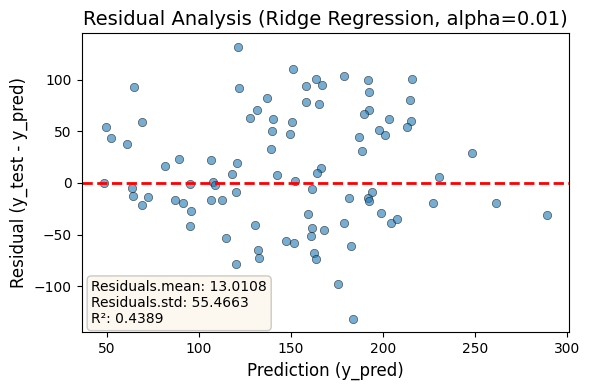

In [118]:
#残差分析
residuals = y_test - y_test_pred

print("残差统计:")
print(f"均值: {np.mean(residuals):.4f}")
print(f"标准差: {np.std(residuals):.4f}")
print(f"最小值: {np.min(residuals):.4f}")
print(f"最大值: {np.max(residuals):.4f}")

#绘制残差图
plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y=0')

#设置标签、标题和图例
plt.xlabel('Prediction (y_pred)', fontsize=12)
plt.ylabel('Residual (y_test - y_pred)', fontsize=12)
plt.title(f'Residual Analysis (Ridge Regression, alpha={best_alpha})', fontsize=14)

#添加统计信息文本框
stats_text = f'Residuals.mean: {np.mean(residuals):.4f}\nResiduals.std: {np.std(residuals):.4f}\nR²: {test_r2:.4f}'
plt.text(0.02, 0.02, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

plt.tight_layout()
plt.show()